## Analyze inter-cluster angles

In [1]:
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import pandas as pd
import numpy as np
import concurrent.futures
import sys
import os

# 
project_workdir = Path("/home/woodydrylab/DiskArray/b05b01002/project_umap_re/")
path_param_sets = project_workdir / "outputs/UMAP/param_table.csv"
path_seed_list = project_workdir / "outputs/UMAP/seeds.txt"

# class holding file paths
class PathFactory:
    def __init__(self, base):
        self._templates = {
            "ica": base / "outputs/InterClusterAngle/{sample}/seed{seed}.csv",
            "cluster": base / "outputs/Seurat/{sample}/clusters.csv",
            "pca": base / "outputs/Seurat/{sample}/pca.csv",
            "embeddings": base / "outputs/UMAP/{sample}/seed{seed}/param_set{param_set}.csv",
            "ica_aligned": base / (
                "outputs/InterClusterAngle/{sample}/per_{n}_embeddings/param_set{param_set}_median.csv"
            ),
            "aligned_rmsd": base / (
                "outputs/AlignEmbeddings/procrustes_alignment/{sample}/"
                "per_{n}_embeddings/param_set{param_set}/batch_{batch}/mean_rmsd.csv"
            ),
            "outdir": base / "notebooks/inter-cluster-angle/temp/results_20260205/{sample}"
        }

    @staticmethod
    def path_maker(template, **kwargs):
        template = str(template)
        for k, v in kwargs.items():
            template = template.replace("{"+ k +"}", str(v))
        return Path(template)

    def __getattr__(self, name):
        template = self._templates[name]
        return lambda **kwargs: PathFactory.path_maker(template, **kwargs)

paths = PathFactory(project_workdir)

### Get or set sample names (from command line or manually define)

In [2]:
if not 'ipykernel' in sys.modules:
    samples = sys.argv[1:]
else:    
    # samples = ["ath", "gar", "lch", "osa", "ptr", "tma", "zma"]
    samples = ["ptr"]

print("[Python] Running samples =", samples)
for sample in samples:
    os.makedirs(paths.outdir(sample=sample), exist_ok=True)

[Python] Running samples = ['ptr']


### Read data

#### 1. UMAP seeds

In [3]:
seeds = [l.strip() for l in open(path_seed_list, "r")]
len(seeds)

1000

#### 2. Parameter sets

In [4]:
param_sets = pd.read_csv(path_param_sets, index_col = 0)
param_sets.describe()

,n_neighbors,min_dist,n_epochs
count,360.000000,360.000000,360.000000
mean,78.000000,0.448333,375.000000
std,68.035711,0.357354,238.816721
min,10.000000,0.000000,100.000000
25%,30.000000,0.100000,175.000000
50%,50.000000,0.400000,350.000000
75%,100.000000,0.800000,550.000000
max,200.000000,0.990000,700.000000


#### 3. Cluster dfs

In [5]:
cluster_dfs = {
    sample: pd.read_csv(
        paths.cluster(sample=sample),
        index_col=0,
        dtype=str,
        header=0,
        names=["cluster"] # overwrite existing headers
    ) for sample in samples
}
cluster_dfs[samples[0]]

,cluster
AAACCTGAGCACCGCT-1,2
AAACCTGCAAGAGTCG-1,5
AAACCTGCACATTCGA-1,0
AAACCTGGTAAATGAC-1,0
AAACCTGGTCATCGGC-1,1
...,...
TTTGTCAGTTCAGGCC-1,1
TTTGTCATCATAGCAC-1,1
TTTGTCATCCGAGCCA-1,2
TTTGTCATCCTTTACA-1,3


#### 4. Inter-cluster angle

In [6]:
ica_dfs = {}
for sample in samples:
    with concurrent.futures.ProcessPoolExecutor(max_workers=48) as executor:
        print(f"sample={sample}", end="")
        # submit jobs to pool
        futures = [
            executor.submit(pd.read_csv, paths.ica(sample=sample, seed=seed)) 
            for seed in seeds
        ]

        # store concurrent results to list
        df_list = []
        for fut in tqdm(
            concurrent.futures.as_completed(futures),
            total=len(futures)
        ):
            df_list.append(fut.result())

        # concat dataframe and map to dict for named access
        print("Concat...")
        ica_dfs[sample] = pd.concat(df_list, ignore_index=True)

        del df_list

sample=ptr

100%|███████████| 1000/1000 [00:11<00:00, 87.26it/s]


Concat...


_**Extract only results of the first 8 clusters**_

In [7]:
for sample, ica_df in ica_dfs.items():
    mask1 = ica_df["vertex"] < 8
    mask2 = ica_df["cluster_a"] < 8
    mask3 = ica_df["cluster_b"] < 8
    ica_dfs[sample] = ica_df[mask1 & mask2 & mask3]
    print(sample, ica_dfs[sample].shape)

ptr (60480000, 6)


_**Convert cosine similarity to degree**_

In [8]:
for sample, ica_df in ica_dfs.items():
    ica_df["radian"] = ica_df["cos_similarity"].apply(np.arccos)
    ica_df["degree"] = ica_df["radian"].apply(np.degrees)

### SD of inter-cluster angle cosine per parameter sets per cluster combinations

Calculate SD per param_set + cluster combo

In [9]:
ica_stds = {}
for sample, df in ica_dfs.items():
    ica_stds[sample] = (
        df
        .groupby(["param_set", "vertex", "cluster_a", "cluster_b"])
        .agg(degree_sd=("degree", "std"),)
    )

In [10]:
ica_avg_stds = pd.DataFrame()
for sample, df in ica_stds.items():
    foo = pd.merge(
        param_sets,
        df.groupby(["param_set"]).mean(),
        left_index=True,
        right_index=True
    )
    foo["sample"] = sample
    ica_avg_stds = pd.concat([ica_avg_stds, foo])
    
ica_avg_stds

,n_neighbors,min_dist,metric,n_epochs,degree_sd,sample
param_set,,,,,,
0,10,0.00,euclidean,100,21.355319,ptr
1,10,0.00,euclidean,200,21.785562,ptr
2,10,0.00,euclidean,500,22.078712,ptr
3,10,0.00,euclidean,700,22.653101,ptr
4,10,0.00,cosine,100,17.432732,ptr
...,...,...,...,...,...,...
355,200,0.99,cosine,700,10.241544,ptr
356,200,0.99,correlation,100,9.492928,ptr
357,200,0.99,correlation,200,11.256299,ptr


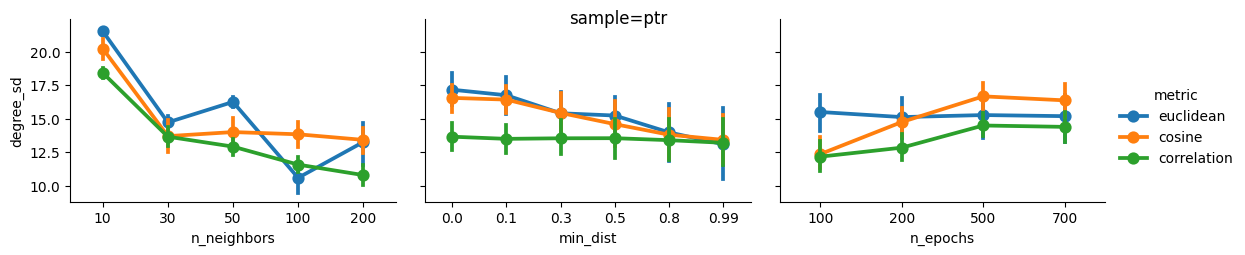

In [11]:
for sample in samples:
    g = sns.PairGrid(
        ica_avg_stds[ica_avg_stds["sample"] == sample],
        x_vars=["n_neighbors", "min_dist", "n_epochs"],
        y_vars=["degree_sd"],
        hue="metric",
        aspect=1.5
    )
    g.map(sns.pointplot) # , fliersize=1, gap=.2
    g.fig.suptitle(f"sample={sample}")
    g.add_legend()
    g.savefig(paths.outdir(sample=sample) / f"degree_sd~params_sample={sample}.svg")

In [12]:
# import pandas as pd
# import matplotlib.pyplot as plt

# def plot_coef(model):
#     # extract coefficients and confidence intervals
#     df = (
#         pd.concat(
#             [model.params, model.conf_int().rename(columns={0: "ci_low", 1: "ci_high"})],
#             axis=1
#         )
#         .reset_index()
#         .rename(columns={"index": "term", 0: "coef"})
#     )
    
#     # drop intercept
#     df = df[df["term"] != "Intercept"]
    
#     # clean term labels
#     df["label"] = (
#         df["term"]
#         .str.replace("C\\(", "", regex=True)
#         .str.replace("\\)", "", regex=True)
#         .str.replace(", Treatment\\(reference=[0-9.]*", "", regex=True)
#         .str.replace("\\[T\\.", " = ", regex=True)
#         .str.replace("\\]", "", regex=True)
#     )
    
#     # sort by effect size
#     df = df.sort_values("coef").reset_index(drop=True)
#     df["y"] = df.index
    
#     # plot coefficient effects with 95% CI
#     fig, ax = plt.subplots(figsize=(6, 8))
#     ax.errorbar(
#         df["coef"],
#         df["y"],
#         xerr=[
#             df["coef"] - df["ci_low"],
#             df["ci_high"] - df["coef"],
#         ],
#         fmt="o",
#         capsize=3
#     )
    
#     ax.axvline(0, linestyle="--", linewidth=1)
#     ax.set_yticks(df["y"])
#     ax.set_yticklabels(df["label"])
#     ax.set_xlabel("Estimated effect on cos_sd relative to reference level")
#     ax.set_title("UMAP hyperparameter effects on embedding instability")
    
#     plt.tight_layout()
#     return fig, ax

In [13]:
# import statsmodels.formula.api as smf

# mask1 = ica_avg_stds["metric"] == "cosine"
# model = smf.ols(
#     "cos_sd ~ "
#     "C(n_neighbors, Treatment(reference=10)) + "
#     "C(min_dist, Treatment(reference=0.0)) + "
#     "C(n_epochs, Treatment(reference=200)) + "
#     "C(sample)",
#     data=ica_avg_stds[mask1]
# ).fit()

# print(model.summary())
# fig, ax = plot_coef(model)
# plt.show()

### Show UMAP embeddings by varying parameters (produce grid of UMAPs)

UMAP plotting function

In [14]:
def plot_umap(path_embeddings, cluster_df, ax, highlights=None, bold=[], palette=None, **kwargs):
    # combinding embeddings with cluster_df
    embeddings = pd.read_csv(path_embeddings, index_col=0)
    embeddings_clusters = pd.merge(embeddings, cluster_df, left_index=True, right_index=True)

    # calculate cluster centroids
    cluster_centroids = embeddings_clusters.groupby(["cluster"]).median()
    cluster_centroids["cluster"] = cluster_centroids.index.tolist()

    # highlight all cluster if `hightlights` is not specified
    if highlights is None:
        highlights = embeddings_clusters["cluster"].unique().tolist()

    # assign non-highlight cluster as lightgray
    if palette is not None:
        palette = palette.copy()
        for clust in palette.keys():
            if clust not in highlights:
                palette[clust] = "lightgray"
        
    # plot cells
    sns.scatterplot(
        embeddings_clusters,
        x="UMAP1",
        y="UMAP2",
        hue="cluster",
        palette=palette,
        ax=ax,
        **kwargs
    )

    # plot cluster centorid and text lable
    for index, row in cluster_centroids.loc[highlights, :].iterrows():
        ax.text(
            x=row["UMAP1"],
            y=row["UMAP2"],
            s=row["cluster"],
            color="black",
            fontsize="large",
            fontweight="black" if row["cluster"] in bold else "normal",
            ha="center",
            va="center"
        )    
    # if highlights is not None:
    #     return palette, cluster_centroids
    #     fig = sns.scatterplot(
    #         cluster_centroids,
    #         x="UMAP1",
    #         y="UMAP2",
    #         c=[palette[c] for c in cluster_centroids["cluster"]],
    #         ax=ax,
    #         s=kwargs.get(s, 4) * 40
    #     )
    ax.relim()
    ax.autoscale_view()
    ax.set_axis_off()
    
    return

In [15]:
for sample in samples:
    for metric in ["euclidean", "cosine", "correlation"]:
        param_sets_subset = param_sets[
            (param_sets["metric"] == metric) &
            (param_sets["n_epochs"] == 200)
        ]
        row_levels = {value: idx for idx, value in enumerate(param_sets_subset["n_neighbors"].unique())}
        col_levels = {value: idx for idx, value in enumerate(param_sets_subset["min_dist"].unique())}
        
        g = sns.FacetGrid(
            param_sets_subset, 
            row="n_neighbors", 
            col="min_dist",
            sharex=False,
            sharey=False
        )
        for idx, row in param_sets_subset.iterrows():
            row_n = row_levels[row["n_neighbors"]]
            col_n = col_levels[row["min_dist"]]
            path_embeddings = paths.embeddings(sample=sample, seed=seeds[0], param_set=idx)
            ax = g.axes[row_n][col_n]
            plot_umap(path_embeddings, cluster_dfs[sample], ax, legend=False, s=1, edgecolors="none")
        
        g.fig.suptitle(f"sample={sample}, metrics={metric}, n_epochs=200", fontsize=10)
        g.fig.subplots_adjust(top=0.95)
        g.savefig(paths.outdir(sample=sample) / f"example_{sample}_{metric}.png")
        plt.close()

### Show extreme UMAP embeddings

Find seeds that give max and min angle per cluster combinations per param sets

In [16]:
from scipy.stats import iqr as scipy_iqr
import numpy as np

def iqr(x):
    return np.percentile(x, 75) - np.percentile(x, 25)

ica_mm_df = pd.DataFrame()
for sample, df in ica_dfs.items():
    # 
    g_df = df.groupby(["param_set", "vertex", "cluster_a", "cluster_b"])

    # 
    ica_max_min = (
        g_df.agg(
            max_degree=("degree", "max"),
            min_degree=("degree", "min"),
            iqr_degree=("degree", iqr),
            degree_sd=("degree", "std")
        )
        .assign(
            max_degree_seed=df.loc[
                g_df["degree"].idxmax().values, "seed"
            ].values,
            min_degree_seed=df.loc[
                g_df["degree"].idxmin().values, "seed"
            ].values,
        )
    )
    ica_max_min["delta_max_min"] = ica_max_min.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
    ica_max_min = pd.merge(ica_max_min, param_sets, left_index=True, right_index=True, how="left")
    ica_max_min["sample"] = sample
    ica_mm_df = pd.concat([ica_mm_df, ica_max_min])

Plot distribution of max(degree) - min(degree)

In [17]:
for sample in samples:
    mask1 = ica_mm_df["sample"] == sample
    g = sns.FacetGrid(
        ica_mm_df[mask1],
        row="n_neighbors",
        col="min_dist",
        hue="metric",
        sharey=False
    )
    g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min")
    g.add_legend()
    g.fig.suptitle(f"samples={sample}", fontsize=10)
    g.tight_layout()
    g.fig.subplots_adjust(top=0.95)
    g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_sample={sample}.svg")
    plt.close()

In [18]:
for sample in samples:
    mask1 = ica_mm_df["sample"] == sample
    g = sns.FacetGrid(
        ica_mm_df[mask1],
        row="n_neighbors", 
        col="min_dist",
        hue="metric",
        sharey=False
    )
    g.map_dataframe(sns.kdeplot, cut=0, x="degree_sd")
    g.add_legend()
    g.fig.suptitle(f"samples={sample}", fontsize=10)
    g.tight_layout()
    g.fig.subplots_adjust(top=0.95)
    g.savefig(paths.outdir(sample=sample) / f"dist_degree_sd_sample={sample}.svg")
    plt.close()

In [19]:
for sample in samples:
    mask1 = ica_mm_df["sample"] == sample
    g = sns.FacetGrid(
        ica_mm_df[mask1],
        row="n_neighbors", 
        col="min_dist",
        hue="metric",
        sharey=False
    )
    g.map_dataframe(sns.kdeplot, cut=0, x="iqr_degree")
    g.add_legend()
    g.fig.suptitle(f"samples={sample}", fontsize=10)
    g.tight_layout()
    g.fig.subplots_adjust(top=0.95)
    g.savefig(paths.outdir(sample=sample) / f"dist_iqr_degree_sample={sample}.svg")
    plt.close()

Plot distribution of max(degree) - min(degree) per vertex

In [20]:
# for sample in samples:
#     mask1 = ica_mm_df["sample"] == sample
#     g = sns.FacetGrid(
#         ica_mm_df[mask1].reset_index(),
#         row="n_neighbors", 
#         col="min_dist",
#         hue="vertex",
#         sharey=False
#     )
#     g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min", linewidth=2)
#     g.add_legend()
#     g.fig.suptitle(f"samples={sample}", fontsize=10)
#     g.tight_layout()
#     g.fig.subplots_adjust(top=0.95)
#     g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_by_vertex_sample={sample}.svg")
#     plt.close()

In [21]:
# for sample in samples:
#     mask1 = ica_mm_df["sample"] == sample
#     g = sns.FacetGrid(
#         ica_mm_df[mask1].reset_index(),
#         row="n_neighbors", 
#         col="min_dist",
#         hue="vertex",
#         sharey=False
#     )
#     g.map_dataframe(sns.kdeplot, cut=0, x="degree_sd", linewidth=2)
#     g.add_legend()
#     g.fig.suptitle(f"samples={sample}", fontsize=10)
#     g.tight_layout()
#     g.fig.subplots_adjust(top=0.95)
#     g.savefig(paths.outdir(sample=sample) / f"dist_degree_sd_by_vertex_sample={sample}.svg")
#     plt.close()

In [22]:
# for sample in samples:
#     mask1 = ica_mm_df["sample"] == sample
#     g = sns.FacetGrid(
#         ica_mm_df[mask1].reset_index(),
#         row="n_neighbors", 
#         col="min_dist",
#         hue="vertex",
#         sharey=False
#     )
#     g.map_dataframe(sns.kdeplot, cut=0, x="iqr_degree", linewidth=2)
#     g.add_legend()
#     g.fig.suptitle(f"samples={sample}", fontsize=10)
#     g.tight_layout()
#     g.fig.subplots_adjust(top=0.95)
#     g.savefig(paths.outdir(sample=sample) / f"dist_iqr_degree_by_vertex_sample={sample}.svg")
#     plt.close()

Plot UMAPs where max(degree), min(degree) are observed

In [23]:
for metric in param_sets["metric"].unique().tolist():
    for sample in samples:
        mask1 = ica_mm_df["sample"] == sample
        mask2 = ica_mm_df["metric"] == metric
        ica_max_min = ica_mm_df[mask1 & mask2]
    
        #
        g_max = sns.FacetGrid(ica_max_min, row="n_neighbors", col="min_dist", sharex=False, sharey=False)
        g_min = sns.FacetGrid(ica_max_min, row="n_neighbors", col="min_dist", sharex=False, sharey=False)
        
        #
        row_levels = {value: idx for idx, value in enumerate(ica_max_min["n_neighbors"].unique())}
        col_levels = {value: idx for idx, value in enumerate(ica_max_min["min_dist"].unique())}
        
        #
        labels = cluster_dfs[sample]["cluster"].unique()
        colors = plt.get_cmap("tab10").colors
        palette = {k: colors[i % len(colors)] for i, k in enumerate(labels)}
        
        #
        for nn in ica_max_min["n_neighbors"].unique():
            for md in ica_max_min["min_dist"].unique():
                # 
                row_n = row_levels[nn]
                col_n = col_levels[md]
        
                # 
                mask1 = ica_max_min["n_neighbors"] == nn
                mask2 = ica_max_min["min_dist"] == md
                mask3 = ica_max_min["n_epochs"] == 200
                ica_diff_subset = ica_max_min.loc[mask1 & mask2 & mask3].reset_index()
                ica_max_diff = ica_diff_subset.loc[ica_diff_subset["delta_max_min"].idxmax(), :]
                
                #
                path_embeddings_max = paths.embeddings(
                    sample=sample,
                    seed=ica_max_diff["max_degree_seed"],
                    param_set=ica_max_diff["param_set"]
                )
                plot_umap(
                    path_embeddings_max,
                    cluster_dfs[sample], 
                    ax=g_max.axes[row_n][col_n], 
                    highlights=ica_max_diff[["vertex", "cluster_a", "cluster_b"]].values.astype(str).tolist(),
                    bold=ica_max_diff[["vertex"]].values.astype(str).tolist(),
                    palette=palette.copy(),
                    legend=False, 
                    s=1,
                    edgecolors="none"
                )
    
                # 
                path_embeddings_min = paths.embeddings(
                    sample=sample,
                    seed=ica_max_diff["min_degree_seed"],
                    param_set=ica_max_diff["param_set"]
                )
                plot_umap(
                    path_embeddings_min, 
                    cluster_dfs[sample],
                    ax=g_min.axes[row_n][col_n], 
                    highlights=ica_max_diff[["vertex", "cluster_a", "cluster_b"]].values.astype(str).tolist(),
                    bold=ica_max_diff[["vertex"]].values.astype(str).tolist(),
                    palette=palette,
                    legend=False, 
                    s=1,
                    edgecolors="none"
                )

        # save and close
        g_max.savefig(paths.outdir(sample=sample) / f"max_umap_metric={metric}_sample={sample}.png")
        g_min.savefig(paths.outdir(sample=sample) / f"min_umap_metric={metric}_sample={sample}.png")
        plt.close("all")

### Test procrustes alignment and:
1. Plot aligned UMAPs
2. Plot stacked UMAPs
3. Plot median UMAP

In [24]:
from scipy.linalg import orthogonal_procrustes
from itertools import combinations
import pandas as pd
import numpy as np
import argparse

def align_to_reference(Y, X):
    """
    Align embedding Y to reference X using orthogonal Procrustes.
    Returns aligned Y and RMSD.
    """
    Xc = X - X.mean(axis=0)
    Yc = Y - Y.mean(axis=0)

    R, _ = orthogonal_procrustes(Yc, Xc)
    Y_aligned = Yc @ R

    rmsd = np.sqrt(((Xc - Y_aligned) ** 2).sum(axis=1).mean())
    return Y_aligned, rmsd

def find_reference(embeddings):
    """
    embeddings: list of (n_samples, n_dims) numpy arrays
    Returns index of reference embedding and per-embedding mean RMSD.
    """
    n = len(embeddings)
    mean_rmsd = np.zeros(n)

    for i in range(n):
        Xi = embeddings[i]
        rmsds = []

        for j in range(n):
            if i == j:
                continue
            _, rmsd = align_to_reference(embeddings[j], Xi)
            rmsds.append(rmsd)

        mean_rmsd[i] = np.mean(rmsds)

    ref_idx = np.argmin(mean_rmsd)
    return ref_idx, mean_rmsd

For each metric, get the param combination that minimize average SD(cos)

In [25]:
# best_combinations = []
# for metric in ica_avg_stds["metric"].unique():
#     mask1 = ica_avg_stds["metric"] == metric
#     mask2 = ica_avg_stds["min_dist"] == 0.3
#     idx_min_metric = ica_avg_stds[mask1 & mask2]["cos_sd"].idxmin()
#     foo = ica_avg_stds.loc[idx_min_metric, ["metric", "n_neighbors", "min_dist", "n_epochs"]].to_dict()
#     best_combinations.append(foo)
# print(*best_combinations, sep="\n")

# uses Seurat default params
best_combinations = [
    {"metric": "euclidean", "n_neighbors": 30, "min_dist": 0.3, "n_epochs": 500},
    {"metric": "cosine", "n_neighbors": 30, "min_dist": 0.3, "n_epochs": 500},
    {"metric": "correlation", "n_neighbors": 30, "min_dist": 0.3, "n_epochs": 500}
]

In [26]:
sample = samples[0]
n_seeds = 25

for param_comb in best_combinations:
    # get param set idx
    conds = []
    for p, v in param_comb.items():
        cond_p = param_sets[p] == v
        if len(conds) == 0:
            conds = cond_p
        else:
            conds = conds & cond_p
            
    param_set_n = param_sets[conds].index.tolist()[0]

    
    # read embeddings
    embeddings_df = [
        pd.read_csv(
            paths.embeddings(sample=sample, seed=seed, param_set=param_set_n),
            index_col=0
        ).sort_index() for seed in seeds[:n_seeds]
    ]
    embeddings = [df.values for df in embeddings_df]

    # calculate RMSD after pairwise alignment
    ref_idx, mean_rmsd = find_reference(embeddings)
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    sns.histplot(mean_rmsd, bins=10, ax=ax)
    fig.suptitle(" | ".join([f"sample = {sample}"] + [f"{k} = {v}" for k, v in param_comb.items()]))
    fig.savefig(paths.outdir(sample=sample) / f"rmsd_metric={param_comb['metric']}_sample={sample}.png")
    plt.close()
    print("Chosen reference seed:", seeds[ref_idx])


    # align embeddings to reference
    X_ref = embeddings[ref_idx]
    aligned_embeddings = []
    for Y in embeddings:
        Y_aligned, _ = align_to_reference(Y, X_ref)
        aligned_embeddings.append(Y_aligned)
    
    # put back cluster and seed columns
    aligned_dfs = []
    for df, Y_aligned, seed in zip(embeddings_df, aligned_embeddings, seeds):
        aligned_df = df.copy()
        aligned_df[["UMAP1", "UMAP2"]] = Y_aligned
        aligned_df = pd.merge(aligned_df, cluster_dfs[sample], left_index=True, right_index=True)
        aligned_df["seed"] = seed
        aligned_dfs.append(aligned_df)
    
    # 1. plot aligned embeddings
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    order_by_mean_rmsd = sorted(range(len(mean_rmsd)), key=mean_rmsd.__getitem__)
    for idx, ax in zip(order_by_mean_rmsd, axes.flatten()):
        sns.scatterplot(
            data=aligned_dfs[idx],
            x="UMAP1",
            y="UMAP2",
            hue="cluster",
            ax=ax,
            legend=False,
            s=1
        )
        ax.set_title(f"seed = {seeds[idx]}")
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        ax.set_xticks([])
        ax.set_yticks([])
    
    fig.suptitle(" | ".join([f"sample = {sample}"] + [f"{k} = {v}" for k, v in param_comb.items()]))
    fig.savefig(paths.outdir(sample=sample) / f"procrustes_aligned_metric={param_comb['metric']}_sample={sample}.png")
    plt.close()


    # 2. plot median embeddings
    concated_df = pd.DataFrame()
    for idx in range(len(aligned_dfs)):
        concated_df = pd.concat([concated_df, aligned_dfs[idx]])
    
    median_embedding = (
        concated_df
        .groupby(concated_df.index)
        .agg(
            UMAP1_median=("UMAP1", "median"),
            UMAP2_median=("UMAP2", "median"),
            cluster=("cluster", "first"),
            seed=("seed", "first")
        )
    )
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    sns.scatterplot(
        data=median_embedding,
        x="UMAP1_median",
        y="UMAP2_median",
        hue="cluster",
        legend=False,
        ax=ax,
        s=4
    )
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.suptitle(" | ".join([f"sample = {sample}"] + [f"{k} = {v}" for k, v in param_comb.items()]))
    fig.savefig(paths.outdir(sample=sample) / f"procrustes_median_metric={param_comb['metric']}_sample={sample}.png")
    plt.close()


    # 3. plot stacked embeddings
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    sns.scatterplot(
        data=concated_df,
        x="UMAP1",
        y="UMAP2",
        hue="cluster",
        legend=False,
        ax=ax,
        alpha=.05,
        s=2
    )
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.suptitle(" | ".join([f"sample = {sample}"] + [f"{k} = {v}" for k, v in param_comb.items()]))
    fig.savefig(paths.outdir(sample=sample) / f"procrustes_stacked_metric={param_comb['metric']}_sample={sample}.png")
   
    plt.close()

Chosen reference seed: 98696
Chosen reference seed: 87397
Chosen reference seed: 38657


# _**Test running procrustes alignment on all seeds (with Snakemake)**_

Align every 10 embeddings

In [27]:
n = 10

### Examine Max ICA difference for seeds used as reference for procrustes alignment

Read dataframe of inter-cluster angles

In [28]:
ica_ref_df = {}

for sample in samples:
    ica_df_slices = []
    for param_set in param_sets.index.tolist():
        ref_seeds = []
        for batch in range(len(seeds) // n):
            mean_rmsd = pd.read_csv(
                paths.aligned_rmsd(sample=sample, n=n, param_set=param_set, batch=batch)
            )
            ref_seed = mean_rmsd.loc[mean_rmsd["mean_rmsd"].idxmin(), "seed"]
            ref_seeds.append(ref_seed)
    
        # subset ica_df
        mask1 = ica_dfs[sample]["param_set"] == param_set
        mask2 = ica_dfs[sample]["seed"].isin(ref_seeds)
        ica_df_slices.append(ica_dfs[sample][mask1 & mask2])
    ica_ref_df[sample] = pd.concat(ica_df_slices)

Calculate max-delta and SD of the angles

In [29]:
ica_ref_mm_df = pd.DataFrame()
for sample, df in ica_ref_df.items():
    tmp = []
    # 
    g_df = df.groupby(["param_set", "vertex", "cluster_a", "cluster_b"])

    # 
    ica_max_min = (
        g_df.agg(
            max_degree=("degree", "max"),
            min_degree=("degree", "min"),
            degree_sd=("degree", "std")
        )
        .assign(
            max_cos_seed=df.loc[
                g_df["degree"].idxmax().values, "seed"
            ].values,
            min_cos_seed=df.loc[
                g_df["degree"].idxmin().values, "seed"
            ].values,
        )
    )
    ica_max_min["delta_max_min"] = ica_max_min.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
    ica_max_min = pd.merge(ica_max_min, param_sets, left_index=True, right_index=True, how="left")
    ica_max_min["sample"] = sample
    tmp.append(ica_max_min)

ica_ref_mm_df = pd.concat(tmp)

Plot distribution

In [30]:
for sample in samples:
    # subset dataframe
    mask1 = ica_ref_mm_df["sample"] == sample
    
    # colored by metric
    g = sns.FacetGrid(
        ica_ref_mm_df[mask1],
        row="n_neighbors",
        col="min_dist",
        hue="metric",
        sharey=False
    )
    g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min")
    g.add_legend()
    g.fig.suptitle(f"samples={sample}", fontsize=10)
    g.tight_layout()
    g.fig.subplots_adjust(top=0.95)
    g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_sample={sample}_references_n={n}.svg")
    plt.close()

    # colored by vertex
    # g = sns.FacetGrid(
    #     ica_ref_mm_df[mask1].reset_index(),
    #     row="n_neighbors", 
    #     col="min_dist",
    #     hue="vertex",
    #     sharey=False
    # )
    # g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min", linewidth=2)
    # g.add_legend()
    # g.fig.suptitle(f"samples={sample}", fontsize=10)
    # g.tight_layout()
    # g.fig.subplots_adjust(top=0.95)
    # g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_by_vertex_sample={sample}_references.svg")
    # plt.close()

### Examine Max ICA difference after orthogonal procrustes alignment

Read dataframe of inter-cluster angles

In [31]:
ica_aligned_df = {}
for sample in samples:
    ica_aligned_list = []
    for param_set in param_sets.index.tolist():
        ica_aligned_param = pd.read_csv(
            paths.ica_aligned(sample=sample, n=n, param_set=param_set)
        )
        mask1 = ica_aligned_param["vertex"] < 8
        mask2 = ica_aligned_param["cluster_a"] < 8
        mask3 = ica_aligned_param["cluster_b"] < 8
        ica_aligned_param = ica_aligned_param[mask1 & mask2 & mask3]
        ica_aligned_param["param_set"] = param_set
        ica_aligned_list.append(ica_aligned_param)
    
    ica_aligned_df[sample] = pd.concat(ica_aligned_list, ignore_index=True)
    ica_aligned_df[sample]["radian"] = ica_aligned_df[sample]["cos_similarity"].apply(np.arccos)
    ica_aligned_df[sample]["degree"] = ica_aligned_df[sample]["radian"].apply(np.degrees)

Calculate max-delta and SD of the angles

In [32]:
ica_aligned_mm_df = pd.DataFrame()
for sample, df in ica_aligned_df.items():
    tmp = []
    # 
    g_df = df.groupby(["param_set", "vertex", "cluster_a", "cluster_b"])

    # 
    ica_max_min = (
        g_df.agg(
            max_degree=("degree", "max"),
            min_degree=("degree", "min"),
            degree_sd=("degree", "std")
        )
        .assign(
            max_cos_batch=df.loc[
                g_df["degree"].idxmax().values, "batch"
            ].values,
            min_cos_batch=df.loc[
                g_df["degree"].idxmin().values, "batch"
            ].values,
        )
    )
    ica_max_min["delta_max_min"] = ica_max_min.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
    ica_max_min = pd.merge(ica_max_min, param_sets, left_index=True, right_index=True, how="left")
    ica_max_min["sample"] = sample
    tmp.append(ica_max_min)

ica_aligned_mm_df = pd.concat(tmp)

Plot distribution

In [33]:
for sample in samples:
    # subset dataframe
    mask1 = ica_aligned_mm_df["sample"] == sample
    
    # colored by metric
    g = sns.FacetGrid(
        ica_aligned_mm_df[mask1],
        row="n_neighbors",
        col="min_dist",
        hue="metric",
        sharey=False
    )
    g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min")
    g.add_legend()
    g.fig.suptitle(f"samples={sample}", fontsize=10)
    g.tight_layout()
    g.fig.subplots_adjust(top=0.95)
    g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_sample={sample}_median_n={n}.svg")
    plt.close()

    # colored by vertex
    # g = sns.FacetGrid(
    #     ica_aligned_mm_df[mask1].reset_index(),
    #     row="n_neighbors", 
    #     col="min_dist",
    #     hue="vertex",
    #     sharey=False
    # )
    # g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min", linewidth=2)
    # g.add_legend()
    # g.fig.suptitle(f"samples={sample}", fontsize=10)
    # g.tight_layout()
    # g.fig.subplots_adjust(top=0.95)
    # g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_by_vertex_sample={sample}_median_n={n}.svg")
    # plt.close()

### Align every `n` embeddings

In [34]:
n = 20

### Examine Max ICA difference for seeds used as reference for procrustes alignment

Read dataframe of inter-cluster angles

In [35]:
ica_ref_df = {}

for sample in samples:
    ica_df_slices = []
    for param_set in param_sets.index.tolist():
        ref_seeds = []
        for batch in range(len(seeds) // n):
            mean_rmsd = pd.read_csv(
                paths.aligned_rmsd(sample=sample, n=n, param_set=param_set, batch=batch)
            )
            ref_seed = mean_rmsd.loc[mean_rmsd["mean_rmsd"].idxmin(), "seed"]
            ref_seeds.append(ref_seed)
    
        # subset ica_df
        mask1 = ica_dfs[sample]["param_set"] == param_set
        mask2 = ica_dfs[sample]["seed"].isin(ref_seeds)
        ica_df_slices.append(ica_dfs[sample][mask1 & mask2])
    ica_ref_df[sample] = pd.concat(ica_df_slices)

Calculate max-delta and SD of the angles

In [36]:
ica_ref_mm_df = pd.DataFrame()
for sample, df in ica_ref_df.items():
    tmp = []
    # 
    g_df = df.groupby(["param_set", "vertex", "cluster_a", "cluster_b"])

    # 
    ica_max_min = (
        g_df.agg(
            max_degree=("degree", "max"),
            min_degree=("degree", "min"),
            degree_sd=("degree", "std")
        )
        .assign(
            max_cos_seed=df.loc[
                g_df["degree"].idxmax().values, "seed"
            ].values,
            min_cos_seed=df.loc[
                g_df["degree"].idxmin().values, "seed"
            ].values,
        )
    )
    ica_max_min["delta_max_min"] = ica_max_min.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
    ica_max_min = pd.merge(ica_max_min, param_sets, left_index=True, right_index=True, how="left")
    ica_max_min["sample"] = sample
    tmp.append(ica_max_min)

ica_ref_mm_df = pd.concat(tmp)

Plot distribution

In [37]:
for sample in samples:
    # subset dataframe
    mask1 = ica_ref_mm_df["sample"] == sample
    
    # colored by metric
    g = sns.FacetGrid(
        ica_ref_mm_df[mask1],
        row="n_neighbors",
        col="min_dist",
        hue="metric",
        sharey=False
    )
    g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min")
    g.add_legend()
    g.fig.suptitle(f"samples={sample}", fontsize=10)
    g.tight_layout()
    g.fig.subplots_adjust(top=0.95)
    g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_sample={sample}_references_n={n}.svg")
    plt.close()

    # colored by vertex
    # g = sns.FacetGrid(
    #     ica_ref_mm_df[mask1].reset_index(),
    #     row="n_neighbors", 
    #     col="min_dist",
    #     hue="vertex",
    #     sharey=False
    # )
    # g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min", linewidth=2)
    # g.add_legend()
    # g.fig.suptitle(f"samples={sample}", fontsize=10)
    # g.tight_layout()
    # g.fig.subplots_adjust(top=0.95)
    # g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_by_vertex_sample={sample}_references.svg")
    # plt.close()

### Examine Max ICA difference after orthogonal procrustes alignment

Read dataframe of inter-cluster angles

In [38]:
ica_aligned_df = {}
for sample in samples:
    ica_aligned_list = []
    for param_set in param_sets.index.tolist():
        ica_aligned_param = pd.read_csv(
            paths.ica_aligned(sample=sample, n=n, param_set=param_set)
        )
        mask1 = ica_aligned_param["vertex"] < 8
        mask2 = ica_aligned_param["cluster_a"] < 8
        mask3 = ica_aligned_param["cluster_b"] < 8
        ica_aligned_param = ica_aligned_param[mask1 & mask2 & mask3]
        ica_aligned_param["param_set"] = param_set
        ica_aligned_list.append(ica_aligned_param)
    
    ica_aligned_df[sample] = pd.concat(ica_aligned_list, ignore_index=True)
    ica_aligned_df[sample]["radian"] = ica_aligned_df[sample]["cos_similarity"].apply(np.arccos)
    ica_aligned_df[sample]["degree"] = ica_aligned_df[sample]["radian"].apply(np.degrees)

Calculate max-delta and SD of the angles

In [39]:
ica_aligned_mm_df = pd.DataFrame()
for sample, df in ica_aligned_df.items():
    tmp = []
    # 
    g_df = df.groupby(["param_set", "vertex", "cluster_a", "cluster_b"])

    # 
    ica_max_min = (
        g_df.agg(
            max_degree=("degree", "max"),
            min_degree=("degree", "min"),
            degree_sd=("degree", "std")
        )
        .assign(
            max_cos_batch=df.loc[
                g_df["degree"].idxmax().values, "batch"
            ].values,
            min_cos_batch=df.loc[
                g_df["degree"].idxmin().values, "batch"
            ].values,
        )
    )
    ica_max_min["delta_max_min"] = ica_max_min.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
    ica_max_min = pd.merge(ica_max_min, param_sets, left_index=True, right_index=True, how="left")
    ica_max_min["sample"] = sample
    tmp.append(ica_max_min)

ica_aligned_mm_df = pd.concat(tmp)

Plot distribution

In [40]:
for sample in samples:
    # subset dataframe
    mask1 = ica_aligned_mm_df["sample"] == sample
    
    # colored by metric
    g = sns.FacetGrid(
        ica_aligned_mm_df[mask1],
        row="n_neighbors",
        col="min_dist",
        hue="metric",
        sharey=False
    )
    g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min")
    g.add_legend()
    g.fig.suptitle(f"samples={sample}", fontsize=10)
    g.tight_layout()
    g.fig.subplots_adjust(top=0.95)
    g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_sample={sample}_median_n={n}.svg")
    plt.close()

    # colored by vertex
    # g = sns.FacetGrid(
    #     ica_aligned_mm_df[mask1].reset_index(),
    #     row="n_neighbors", 
    #     col="min_dist",
    #     hue="vertex",
    #     sharey=False
    # )
    # g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min", linewidth=2)
    # g.add_legend()
    # g.fig.suptitle(f"samples={sample}", fontsize=10)
    # g.tight_layout()
    # g.fig.subplots_adjust(top=0.95)
    # g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_by_vertex_sample={sample}_median_n={n}.svg")
    # plt.close()

### Align every `n` embeddings

In [41]:
n = 50

### Examine Max ICA difference for seeds used as reference for procrustes alignment

Read dataframe of inter-cluster angles

In [42]:
ica_ref_df = {}

for sample in samples:
    ica_df_slices = []
    for param_set in param_sets.index.tolist():
        ref_seeds = []
        for batch in range(len(seeds) // n):
            mean_rmsd = pd.read_csv(
                paths.aligned_rmsd(sample=sample, n=n, param_set=param_set, batch=batch)
            )
            ref_seed = mean_rmsd.loc[mean_rmsd["mean_rmsd"].idxmin(), "seed"]
            ref_seeds.append(ref_seed)
    
        # subset ica_df
        mask1 = ica_dfs[sample]["param_set"] == param_set
        mask2 = ica_dfs[sample]["seed"].isin(ref_seeds)
        ica_df_slices.append(ica_dfs[sample][mask1 & mask2])
    ica_ref_df[sample] = pd.concat(ica_df_slices)

Calculate max-delta and SD of the angles

In [43]:
ica_ref_mm_df = pd.DataFrame()
for sample, df in ica_ref_df.items():
    tmp = []
    # 
    g_df = df.groupby(["param_set", "vertex", "cluster_a", "cluster_b"])

    # 
    ica_max_min = (
        g_df.agg(
            max_degree=("degree", "max"),
            min_degree=("degree", "min"),
            degree_sd=("degree", "std")
        )
        .assign(
            max_cos_seed=df.loc[
                g_df["degree"].idxmax().values, "seed"
            ].values,
            min_cos_seed=df.loc[
                g_df["degree"].idxmin().values, "seed"
            ].values,
        )
    )
    ica_max_min["delta_max_min"] = ica_max_min.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
    ica_max_min = pd.merge(ica_max_min, param_sets, left_index=True, right_index=True, how="left")
    ica_max_min["sample"] = sample
    tmp.append(ica_max_min)

ica_ref_mm_df = pd.concat(tmp)

Plot distribution

In [44]:
for sample in samples:
    # subset dataframe
    mask1 = ica_ref_mm_df["sample"] == sample
    
    # colored by metric
    g = sns.FacetGrid(
        ica_ref_mm_df[mask1],
        row="n_neighbors",
        col="min_dist",
        hue="metric",
        sharey=False
    )
    g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min")
    g.add_legend()
    g.fig.suptitle(f"samples={sample}", fontsize=10)
    g.tight_layout()
    g.fig.subplots_adjust(top=0.95)
    g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_sample={sample}_references_n={n}.svg")
    plt.close()

    # colored by vertex
    # g = sns.FacetGrid(
    #     ica_ref_mm_df[mask1].reset_index(),
    #     row="n_neighbors", 
    #     col="min_dist",
    #     hue="vertex",
    #     sharey=False
    # )
    # g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min", linewidth=2)
    # g.add_legend()
    # g.fig.suptitle(f"samples={sample}", fontsize=10)
    # g.tight_layout()
    # g.fig.subplots_adjust(top=0.95)
    # g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_by_vertex_sample={sample}_references.svg")
    # plt.close()

### Examine Max ICA difference after orthogonal procrustes alignment

Read dataframe of inter-cluster angles

In [45]:
ica_aligned_df = {}
for sample in samples:
    ica_aligned_list = []
    for param_set in param_sets.index.tolist():
        ica_aligned_param = pd.read_csv(
            paths.ica_aligned(sample=sample, n=n, param_set=param_set)
        )
        mask1 = ica_aligned_param["vertex"] < 8
        mask2 = ica_aligned_param["cluster_a"] < 8
        mask3 = ica_aligned_param["cluster_b"] < 8
        ica_aligned_param = ica_aligned_param[mask1 & mask2 & mask3]
        ica_aligned_param["param_set"] = param_set
        ica_aligned_list.append(ica_aligned_param)
    
    ica_aligned_df[sample] = pd.concat(ica_aligned_list, ignore_index=True)
    ica_aligned_df[sample]["radian"] = ica_aligned_df[sample]["cos_similarity"].apply(np.arccos)
    ica_aligned_df[sample]["degree"] = ica_aligned_df[sample]["radian"].apply(np.degrees)

Calculate max-delta and SD of the angles

In [46]:
ica_aligned_mm_df = pd.DataFrame()
for sample, df in ica_aligned_df.items():
    tmp = []
    # 
    g_df = df.groupby(["param_set", "vertex", "cluster_a", "cluster_b"])

    # 
    ica_max_min = (
        g_df.agg(
            max_degree=("degree", "max"),
            min_degree=("degree", "min"),
            degree_sd=("degree", "std")
        )
        .assign(
            max_cos_batch=df.loc[
                g_df["degree"].idxmax().values, "batch"
            ].values,
            min_cos_batch=df.loc[
                g_df["degree"].idxmin().values, "batch"
            ].values,
        )
    )
    ica_max_min["delta_max_min"] = ica_max_min.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
    ica_max_min = pd.merge(ica_max_min, param_sets, left_index=True, right_index=True, how="left")
    ica_max_min["sample"] = sample
    tmp.append(ica_max_min)

ica_aligned_mm_df = pd.concat(tmp)

Plot distribution

In [47]:
# for sample in samples:
#     # subset dataframe
#     mask1 = ica_aligned_mm_df["sample"] == sample
    
#     # colored by metric
#     g = sns.FacetGrid(
#         ica_aligned_mm_df[mask1],
#         row="n_neighbors",
#         col="min_dist",
#         hue="metric",
#         sharey=False
#     )
#     g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min")
#     g.add_legend()
#     g.fig.suptitle(f"samples={sample}", fontsize=10)
#     g.tight_layout()
#     g.fig.subplots_adjust(top=0.95)
#     g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_sample={sample}_median_n={n}.svg")
#     plt.close()

#     # colored by vertex
#     g = sns.FacetGrid(
#         ica_aligned_mm_df[mask1].reset_index(),
#         row="n_neighbors", 
#         col="min_dist",
#         hue="vertex",
#         sharey=False
#     )
#     g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min", linewidth=2)
#     g.add_legend()
#     g.fig.suptitle(f"samples={sample}", fontsize=10)
#     g.tight_layout()
#     g.fig.subplots_adjust(top=0.95)
#     g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_by_vertex_sample={sample}_median_n={n}.svg")
#     plt.close()

### Align every `n` embeddings

In [48]:
n = 100

### Examine Max ICA difference for seeds used as reference for procrustes alignment

Read dataframe of inter-cluster angles

In [49]:
ica_ref_df = {}

for sample in samples:
    ica_df_slices = []
    for param_set in param_sets.index.tolist():
        ref_seeds = []
        for batch in range(len(seeds) // n):
            mean_rmsd = pd.read_csv(
                paths.aligned_rmsd(sample=sample, n=n, param_set=param_set, batch=batch)
            )
            ref_seed = mean_rmsd.loc[mean_rmsd["mean_rmsd"].idxmin(), "seed"]
            ref_seeds.append(ref_seed)
    
        # subset ica_df
        mask1 = ica_dfs[sample]["param_set"] == param_set
        mask2 = ica_dfs[sample]["seed"].isin(ref_seeds)
        ica_df_slices.append(ica_dfs[sample][mask1 & mask2])
    ica_ref_df[sample] = pd.concat(ica_df_slices)

Calculate max-delta and SD of the angles

In [50]:
ica_ref_mm_df = pd.DataFrame()
for sample, df in ica_ref_df.items():
    tmp = []
    # 
    g_df = df.groupby(["param_set", "vertex", "cluster_a", "cluster_b"])

    # 
    ica_max_min = (
        g_df.agg(
            max_degree=("degree", "max"),
            min_degree=("degree", "min"),
            degree_sd=("degree", "std")
        )
        .assign(
            max_cos_seed=df.loc[
                g_df["degree"].idxmax().values, "seed"
            ].values,
            min_cos_seed=df.loc[
                g_df["degree"].idxmin().values, "seed"
            ].values,
        )
    )
    ica_max_min["delta_max_min"] = ica_max_min.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
    ica_max_min = pd.merge(ica_max_min, param_sets, left_index=True, right_index=True, how="left")
    ica_max_min["sample"] = sample
    tmp.append(ica_max_min)

ica_ref_mm_df = pd.concat(tmp)

Plot distribution

In [51]:
for sample in samples:
    # subset dataframe
    mask1 = ica_ref_mm_df["sample"] == sample
    
    # colored by metric
    g = sns.FacetGrid(
        ica_ref_mm_df[mask1],
        row="n_neighbors",
        col="min_dist",
        hue="metric",
        sharey=False
    )
    g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min")
    g.add_legend()
    g.fig.suptitle(f"samples={sample}", fontsize=10)
    g.tight_layout()
    g.fig.subplots_adjust(top=0.95)
    g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_sample={sample}_references_n={n}.svg")
    plt.close()

    # colored by vertex
    # g = sns.FacetGrid(
    #     ica_ref_mm_df[mask1].reset_index(),
    #     row="n_neighbors", 
    #     col="min_dist",
    #     hue="vertex",
    #     sharey=False
    # )
    # g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min", linewidth=2)
    # g.add_legend()
    # g.fig.suptitle(f"samples={sample}", fontsize=10)
    # g.tight_layout()
    # g.fig.subplots_adjust(top=0.95)
    # g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_by_vertex_sample={sample}_references.svg")
    # plt.close()

### Examine Max ICA difference after orthogonal procrustes alignment

Read dataframe of inter-cluster angles

In [52]:
ica_aligned_df = {}
for sample in samples:
    ica_aligned_list = []
    for param_set in param_sets.index.tolist():
        ica_aligned_param = pd.read_csv(
            paths.ica_aligned(sample=sample, n=n, param_set=param_set)
        )
        mask1 = ica_aligned_param["vertex"] < 8
        mask2 = ica_aligned_param["cluster_a"] < 8
        mask3 = ica_aligned_param["cluster_b"] < 8
        ica_aligned_param = ica_aligned_param[mask1 & mask2 & mask3]
        ica_aligned_param["param_set"] = param_set
        ica_aligned_list.append(ica_aligned_param)
    
    ica_aligned_df[sample] = pd.concat(ica_aligned_list, ignore_index=True)
    ica_aligned_df[sample]["radian"] = ica_aligned_df[sample]["cos_similarity"].apply(np.arccos)
    ica_aligned_df[sample]["degree"] = ica_aligned_df[sample]["radian"].apply(np.degrees)

Calculate max-delta and SD of the angles

In [53]:
ica_aligned_mm_df = pd.DataFrame()
for sample, df in ica_aligned_df.items():
    tmp = []
    # 
    g_df = df.groupby(["param_set", "vertex", "cluster_a", "cluster_b"])

    # 
    ica_max_min = (
        g_df.agg(
            max_degree=("degree", "max"),
            min_degree=("degree", "min"),
            degree_sd=("degree", "std")
        )
        .assign(
            max_cos_batch=df.loc[
                g_df["degree"].idxmax().values, "batch"
            ].values,
            min_cos_batch=df.loc[
                g_df["degree"].idxmin().values, "batch"
            ].values,
        )
    )
    ica_max_min["delta_max_min"] = ica_max_min.apply(lambda x: abs(x["max_degree"] - x["min_degree"]), axis=1)
    ica_max_min = pd.merge(ica_max_min, param_sets, left_index=True, right_index=True, how="left")
    ica_max_min["sample"] = sample
    tmp.append(ica_max_min)

ica_aligned_mm_df = pd.concat(tmp)

Plot distribution

In [54]:
for sample in samples:
    # subset dataframe
    mask1 = ica_aligned_mm_df["sample"] == sample
    
    # colored by metric
    g = sns.FacetGrid(
        ica_aligned_mm_df[mask1],
        row="n_neighbors",
        col="min_dist",
        hue="metric",
        sharey=False
    )
    g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min")
    g.add_legend()
    g.fig.suptitle(f"samples={sample}", fontsize=10)
    g.tight_layout()
    g.fig.subplots_adjust(top=0.95)
    g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_sample={sample}_median_n={n}.svg")
    plt.close()

    # colored by vertex
    # g = sns.FacetGrid(
    #     ica_aligned_mm_df[mask1].reset_index(),
    #     row="n_neighbors", 
    #     col="min_dist",
    #     hue="vertex",
    #     sharey=False
    # )
    # g.map_dataframe(sns.kdeplot, cut=0, x="delta_max_min", linewidth=2)
    # g.add_legend()
    # g.fig.suptitle(f"samples={sample}", fontsize=10)
    # g.tight_layout()
    # g.fig.subplots_adjust(top=0.95)
    # g.savefig(paths.outdir(sample=sample) / f"dist_max_diff_by_vertex_sample={sample}_median_n={n}.svg")
    # plt.close()